In [ ]:
import os
os.makedirs('output_images', exist_ok=True)


# Raman Spectroscopy — Fingerprint Region (500–2000 cm⁻¹)

| Parameter | Value |
|-----------|-------|
| Files | `sec-10_power-{40,50,60,70}_i-10.xlsx` |
| Raman shift column | col 2 (`Raman Shift`) |
| Intensity column | col 3 (`Dark Subtracted #1`) |
| Baseline | ALS (Asymmetric Least Squares) |
| Smoothing | Savitzky-Golay |
| Plot region | 500–2000 cm⁻¹ (fingerprint) |

---

## Cell 1 — Imports, style & helpers

In [23]:
import os, warnings, numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, matplotlib.ticker as ticker
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter, find_peaks
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'axes.labelsize': 13, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'legend.fontsize': 11, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'axes.linewidth': 1.3,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 5, 'ytick.major.size': 5,
    'xtick.minor.size': 3, 'ytick.minor.size': 3,
    'figure.dpi': 100,
})

def als_baseline(y, lam=1e5, p=0.01, max_iter=10):
    m = len(y)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(m - 2, m))
    H = lam * D.T.dot(D)
    w = np.ones(m)
    for _ in range(max_iter):
        W = sparse.diags(w)
        z = spsolve(W + H, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

DATA_DIR = '.'
FILE_MAP  = {
    '40%': 'sec-10_power-40_i-10.xlsx',
    '50%': 'sec-10_power-50_i-10.xlsx',
    '60%': 'sec-10_power-60_i-10.xlsx',
    '70%': 'sec-10_power-70_i-10.xlsx',
}
COL_SHIFT, COL_INTENSITY, SKIP_ROWS = 2, 3, 1
X_MIN, X_MAX = 500, 2000
COLORS = {'40%': '#1f77b4', '50%': '#d62728', '60%': '#2ca02c', '70%': '#9467bd'}
ANNOTATIONS = []
print("Setup complete \u2714")


Setup complete ✔


## Cell 2 — Load raw data

> **Excel structure:**  Cols 0–1 = metadata rows 0–2 only. **Col 2** = Raman Shift · **Col 3** = Dark Subtracted #1


In [24]:
raw_data = {}
for label, fname in FILE_MAP.items():
    df = pd.read_excel(os.path.join(DATA_DIR, fname), header=None,
                        skiprows=SKIP_ROWS)
    x = pd.to_numeric(df.iloc[:, COL_SHIFT],     errors='coerce').values
    y = pd.to_numeric(df.iloc[:, COL_INTENSITY],  errors='coerce').values
    valid = ~(np.isnan(x) | np.isnan(y))
    x, y  = x[valid], y[valid]
    idx   = np.argsort(x); x, y = x[idx], y[idx]
    raw_data[label] = (x.copy(), y.copy())
    print(f'  {label}  \u2192  {len(x):,} pts | shift: {x.min():.1f}\u2013{x.max():.1f} cm\u207b\u00b9')
print('\nAll files loaded \u2714')


  40%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹
  50%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹
  60%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹
  70%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹

All files loaded ✔


## Cell 3 — ALS baseline correction

In [25]:
corrected_data = {}
for label, (x, y) in raw_data.items():
    bline  = als_baseline(y)
    y_corr = np.clip(y - bline, 0, None)
    corrected_data[label] = (x.copy(), y_corr)
    print(f'  {label}  max corrected: {y_corr.max():,.1f}')
print('\nBaseline correction done \u2714')


  40%  max corrected: 4,619.6
  50%  max corrected: 6,880.8
  60%  max corrected: 7,420.5
  70%  max corrected: 8,666.4

Baseline correction done ✔


## Cell 4 — Filter to fingerprint region (500–2000 cm⁻¹)

In [26]:
filtered_data = {}
for label, (x, y) in corrected_data.items():
    mask = (x >= X_MIN) & (x <= X_MAX)
    filtered_data[label] = (x[mask].copy(), y[mask].copy())
    print(f'  {label}  \u2192  {mask.sum():,} pts in {X_MIN}\u2013{X_MAX} cm\u207b\u00b9')
print('\nFiltering done \u2714')


  40%  →  993 pts in 500–2000 cm⁻¹
  50%  →  993 pts in 500–2000 cm⁻¹
  60%  →  993 pts in 500–2000 cm⁻¹
  70%  →  993 pts in 500–2000 cm⁻¹

Filtering done ✔


## Cell 5 — Normalise for overlay (visualisation only)

In [27]:
normalised_data = {}
for label, (x_f, y_f) in filtered_data.items():
    y_max  = y_f.max() if y_f.size > 0 else 1.0
    y_norm = y_f / y_max if y_max > 0 else y_f.copy()
    normalised_data[label] = (x_f.copy(), y_norm)
print('Normalisation done (visualisation copies only) \u2714')


Normalisation done (visualisation copies only) ✔


## Cell 6 — Combined Raman plot (all 4 power levels)

> **Standard Raman convention:** x-axis reversed (2000 → 500 cm⁻¹)


Figure saved → raman_500_2000.png  (300 dpi, PNG) ✔


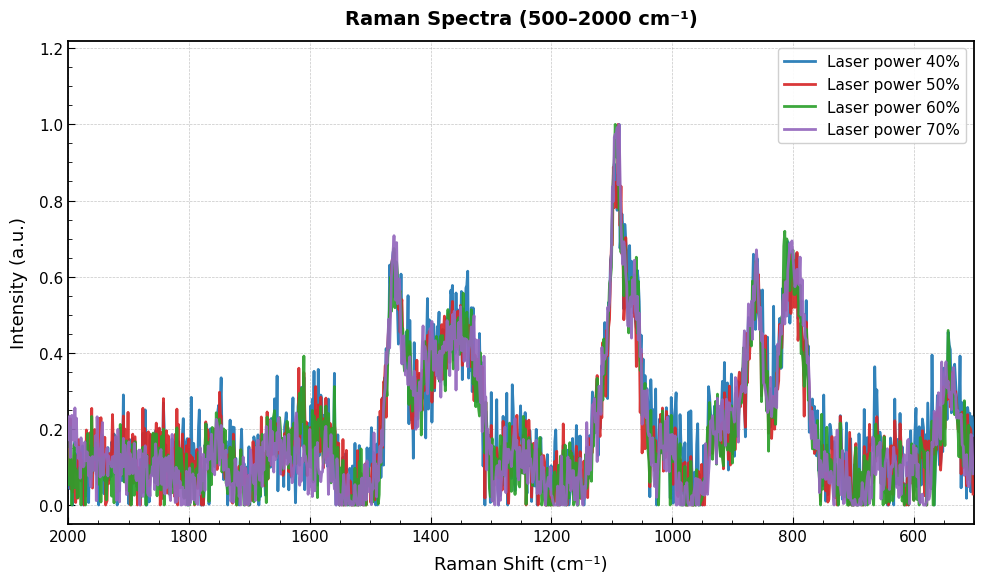

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, (x_f, y_norm) in normalised_data.items():
    ax.plot(x_f, y_norm, color=COLORS[label], linewidth=2,
            label=f'Laser power {label}', alpha=0.92, zorder=3)
for shift, lbl in ANNOTATIONS:
    ax.axvline(x=shift, color='#555555', linestyle='--',
               linewidth=1.1, alpha=0.75, zorder=2)
    ax.text(shift - 8, 1.07, lbl, ha='right', va='top',
            fontsize=8.5, color='#444444', linespacing=1.4)
ax.set_xlim(X_MAX, X_MIN); ax.set_ylim(-0.05, 1.22)
ax.set_xlabel('Raman Shift (cm\u207b\u00b9)', labelpad=8)
ax.set_ylabel('Intensity (a.u.)', labelpad=8)
ax.set_title('Raman Spectra (500\u20132000 cm\u207b\u00b9)', pad=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5,
        alpha=0.45, color='grey', zorder=1)
ax.set_axisbelow(True)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc', handlelength=2)
plt.tight_layout()
fig.savefig('output_images/raman_500_2000.png', dpi=300, bbox_inches='tight', format='png')
print('Figure saved \u2192 output_images/raman_500_2000.png  (300 dpi, PNG) \u2714')
plt.show()


## Cell 7 — Peak detection with markers

Peak figure saved → raman_500_2000_peaks.png  (300 dpi) ✔


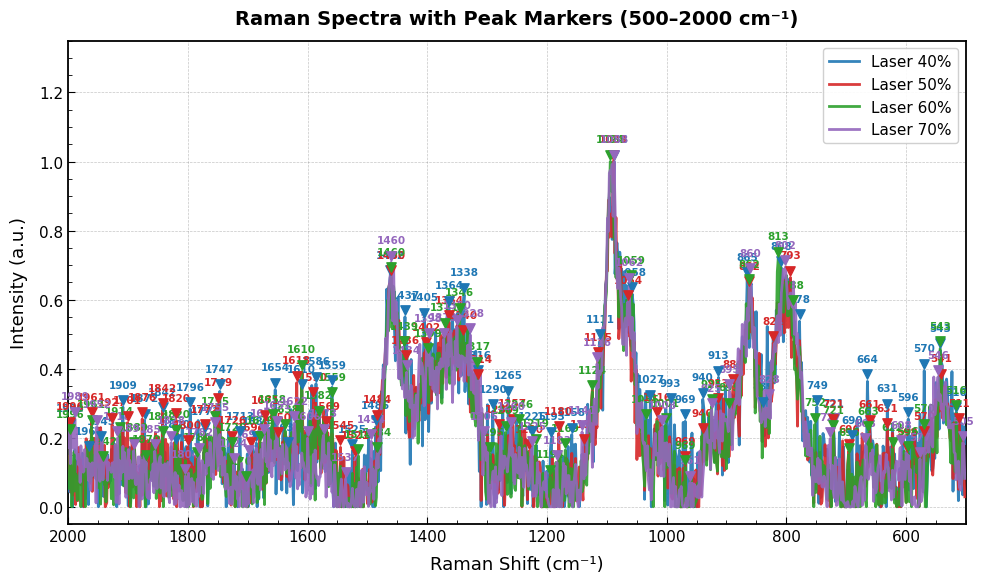

In [29]:
PEAK_PROMINENCE = 0.04
PEAK_DISTANCE   = 15
fig2, ax2 = plt.subplots(figsize=(10, 6))
for label, (x_f, y_norm) in normalised_data.items():
    peaks, _ = find_peaks(y_norm, prominence=PEAK_PROMINENCE, distance=PEAK_DISTANCE)
    ax2.plot(x_f, y_norm, color=COLORS[label], linewidth=2,
             label=f'Laser {label}', alpha=0.90, zorder=3)
    ax2.scatter(x_f[peaks], y_norm[peaks] + 0.02,
                color=COLORS[label], marker='v', s=45, zorder=5)
    for pk in peaks:
        ax2.annotate(f'{x_f[pk]:.0f}',
                     xy=(x_f[pk], y_norm[pk] + 0.05),
                     ha='center', va='bottom', fontsize=7.5,
                     color=COLORS[label], fontweight='semibold')
for shift, lbl in ANNOTATIONS:
    ax2.axvline(x=shift, color='#555555', linestyle='--',
                linewidth=1.1, alpha=0.75, zorder=2)
    ax2.text(shift - 8, 1.18, lbl, ha='right', va='top',
             fontsize=8.5, color='#444444', linespacing=1.4)
ax2.set_xlim(X_MAX, X_MIN); ax2.set_ylim(-0.05, 1.35)
ax2.set_xlabel('Raman Shift (cm\u207b\u00b9)', labelpad=8)
ax2.set_ylabel('Intensity (a.u.)', labelpad=8)
ax2.set_title('Raman Spectra with Peak Markers (500\u20132000 cm\u207b\u00b9)', pad=12)
ax2.grid(True, which='major', linestyle='--', linewidth=0.5,
         alpha=0.45, color='grey', zorder=1)
ax2.set_axisbelow(True)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax2.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc')
plt.tight_layout()
fig2.savefig('output_images/raman_500_2000_peaks.png', dpi=300, bbox_inches='tight', format='png')
print('Peak figure saved \u2192 output_images/raman_500_2000_peaks.png  (300 dpi) \u2714')
plt.show()


## Cell 8 — Peak summary table

In [30]:
rows = []
for label, (x_f, y_norm) in normalised_data.items():
    peaks, props = find_peaks(y_norm, prominence=PEAK_PROMINENCE,
                              distance=PEAK_DISTANCE)
    for i, pk in enumerate(peaks):
        rows.append({
            'Power':               label,
            'Raman Shift (cm\u207b\u00b9)': round(float(x_f[pk]), 1),
            'Norm. Intensity':     round(float(y_norm[pk]), 4),
            'Prominence':          round(float(props['prominences'][i]), 4),
        })
peak_df = (pd.DataFrame(rows)
           .sort_values(['Power', 'Raman Shift (cm\u207b\u00b9)'])
           .reset_index(drop=True))
peak_df.to_csv('output_images/raman_peaks_table.csv', index=False)
print(f'Saved {len(peak_df)} peaks \u2192 output_images/raman_peaks_table.csv \u2714')
peak_df


Saved 198 peaks → raman_peaks_table.csv ✔


,Power,Raman Shift (cm⁻¹),Norm. Intensity,Prominence
0,40%,516.0,0.2693,0.2241
1,40%,542.8,0.4540,0.4363
2,40%,569.5,0.3941,0.3941
3,40%,596.1,0.2541,0.2541
4,40%,631.2,0.2783,0.2783
...,...,...,...,...
193,70%,1855.5,0.1607,0.1490
194,70%,1890.6,0.1623,0.0811
195,70%,1917.7,0.1988,0.1861
196,70%,1952.2,0.2318,0.2204


## Cell 9 — Individual plots (one figure per power level)

> ALS-corrected · max-normalised · 300 dpi PNG


  Saved → raman_500_2000_power_40pct.png  (300 dpi) ✔


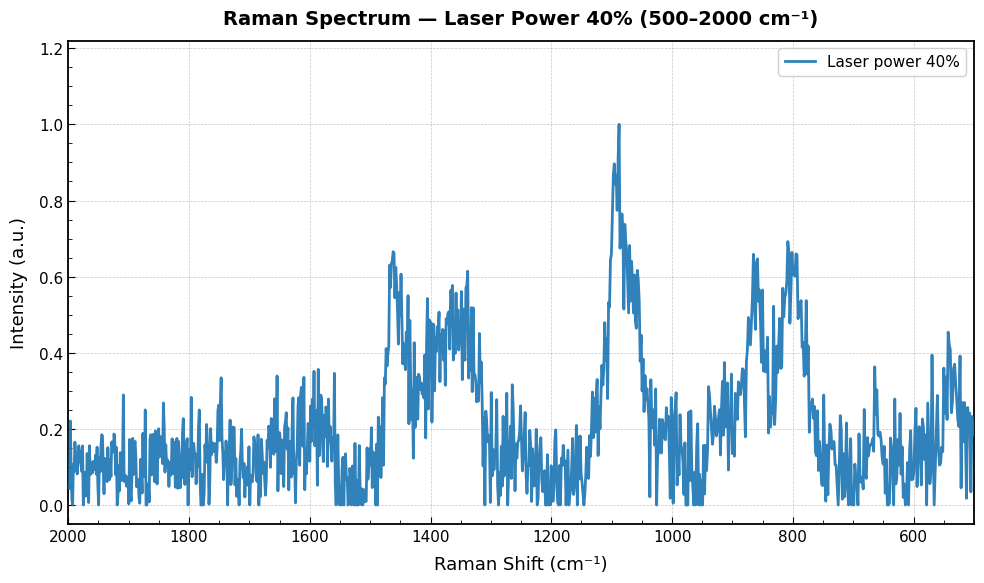

  Saved → raman_500_2000_power_50pct.png  (300 dpi) ✔


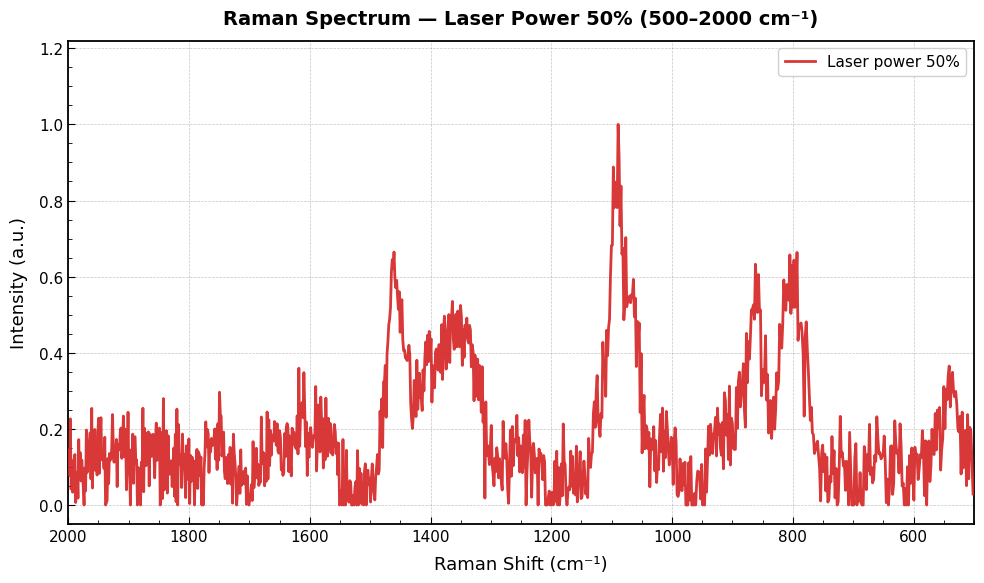

  Saved → raman_500_2000_power_60pct.png  (300 dpi) ✔


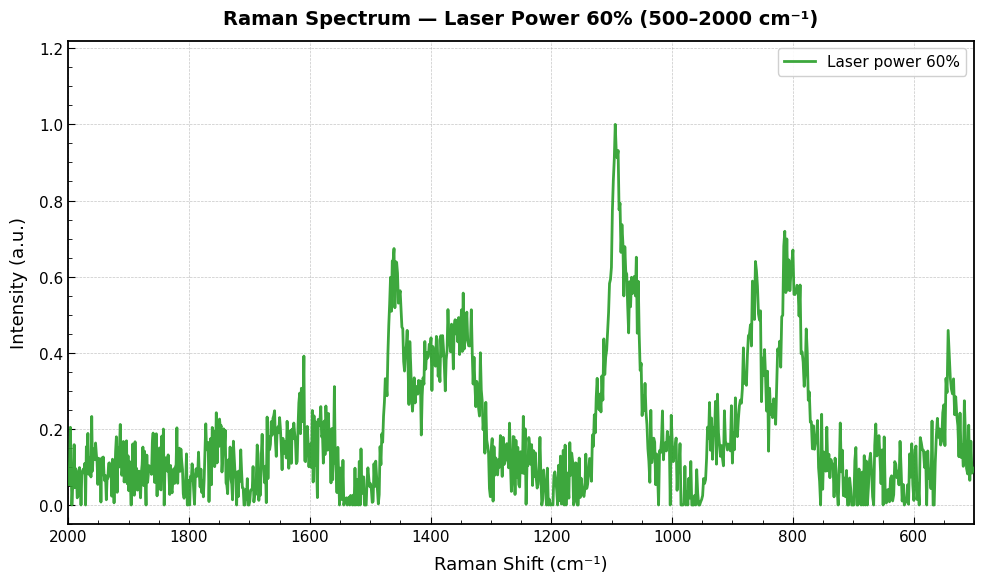

  Saved → raman_500_2000_power_70pct.png  (300 dpi) ✔


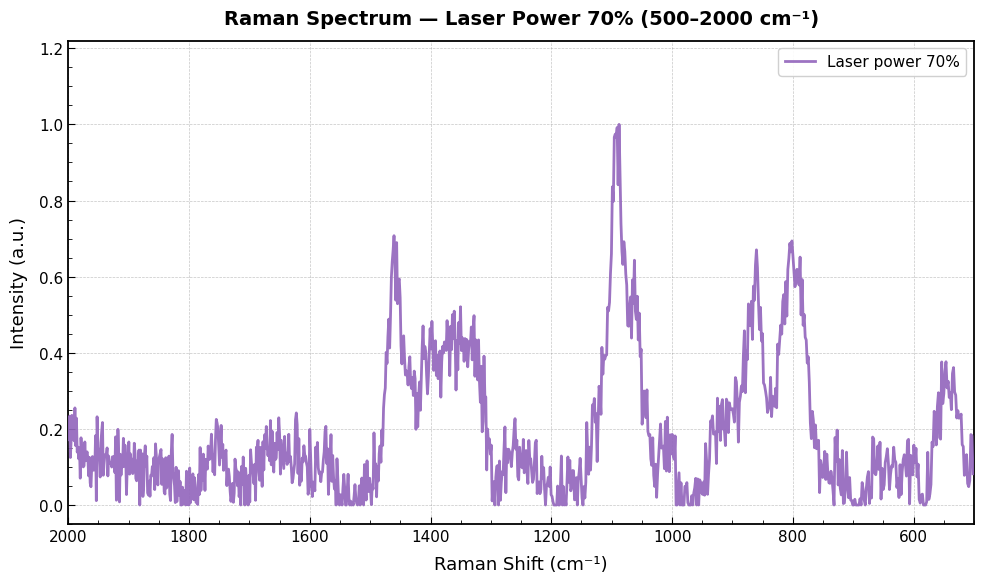


4 individual figures saved ✔


In [31]:
saved_files = []
for label, (x_f, y_f) in filtered_data.items():
    y_max  = y_f.max() if y_f.size > 0 else 1.0
    y_norm = y_f / y_max if y_max > 0 else y_f.copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_f, y_norm, color=COLORS[label], linewidth=2,
            label=f'Laser power {label}', alpha=0.92, zorder=3)
    for shift, lbl in ANNOTATIONS:
        ax.axvline(x=shift, color='#555555', linestyle='--',
                   linewidth=1.1, alpha=0.75, zorder=2)
        ax.text(shift - 8, 1.07, lbl, ha='right', va='top',
                fontsize=8.5, color='#444444', linespacing=1.4)
    ax.set_xlim(X_MAX, X_MIN); ax.set_ylim(-0.05, 1.22)
    ax.set_xlabel('Raman Shift (cm\u207b\u00b9)', labelpad=8)
    ax.set_ylabel('Intensity (a.u.)', labelpad=8)
    ax.set_title(f'Raman Spectrum \u2014 Laser Power {label} (500\u20132000 cm\u207b\u00b9)',
                 pad=12)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5,
            alpha=0.45, color='grey', zorder=1)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc')
    plt.tight_layout()
    pct = label.replace('%', 'pct')
    out = f'output_images/raman_500_2000_power_{pct}.png'
    fig.savefig(out, dpi=300, bbox_inches='tight', format='png')
    saved_files.append(out)
    print(f'  Saved \u2192 {out}  (300 dpi) \u2714')
    plt.show()
print(f'\n{len(saved_files)} individual figures saved \u2714')


---
## Cell 10 — Smoothed spectra (Savitzky-Golay filter)

Applies a **Savitzky-Golay filter** to each ALS-corrected spectrum.

| Parameter | Value |
|-----------|-------|
| Algorithm | `scipy.signal.savgol_filter` |
| Window length | 25 points |
| Polynomial order | 4 |

> Each figure shows the **grey raw trace** plus the **coloured smoothed trace** for direct comparison.
> Figures exported at **300 dpi** as individual PNGs.


In [32]:
import os, warnings, numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, matplotlib.ticker as ticker
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter, find_peaks
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'axes.labelsize': 13, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'legend.fontsize': 11, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'axes.linewidth': 1.3,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 5, 'ytick.major.size': 5,
    'xtick.minor.size': 3, 'ytick.minor.size': 3,
    'figure.dpi': 100,
})

def als_baseline(y, lam=1e5, p=0.01, max_iter=10):
    m = len(y)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(m - 2, m))
    H = lam * D.T.dot(D)
    w = np.ones(m)
    for _ in range(max_iter):
        W = sparse.diags(w)
        z = spsolve(W + H, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

DATA_DIR = '.'
FILE_MAP  = {
    '40%': 'sec-10_power-40_i-10.xlsx',
    '50%': 'sec-10_power-50_i-10.xlsx',
    '60%': 'sec-10_power-60_i-10.xlsx',
    '70%': 'sec-10_power-70_i-10.xlsx',
}
COL_SHIFT, COL_INTENSITY, SKIP_ROWS = 2, 3, 1
X_MIN, X_MAX = 500, 2000
COLORS = {'40%': '#1f77b4', '50%': '#d62728', '60%': '#2ca02c', '70%': '#9467bd'}
ANNOTATIONS = []
raw_data = {}
for label, fname in FILE_MAP.items():
    df = pd.read_excel(os.path.join(DATA_DIR, fname), header=None,
                        skiprows=SKIP_ROWS)
    x = pd.to_numeric(df.iloc[:, COL_SHIFT],     errors='coerce').values
    y = pd.to_numeric(df.iloc[:, COL_INTENSITY],  errors='coerce').values
    valid = ~(np.isnan(x) | np.isnan(y))
    x, y  = x[valid], y[valid]
    idx   = np.argsort(x); x, y = x[idx], y[idx]
    raw_data[label] = (x.copy(), y.copy())
    print(f'  {label}  \u2192  {len(x):,} pts | shift: {x.min():.1f}\u2013{x.max():.1f} cm\u207b\u00b9')
print('\nAll files loaded \u2714')
corrected_data = {}
for label, (x, y) in raw_data.items():
    bline  = als_baseline(y)
    y_corr = np.clip(y - bline, 0, None)
    corrected_data[label] = (x.copy(), y_corr)
    print(f'  {label}  max corrected: {y_corr.max():,.1f}')
print('\nBaseline correction done \u2714')
filtered_data = {}
for label, (x, y) in corrected_data.items():
    mask = (x >= X_MIN) & (x <= X_MAX)
    filtered_data[label] = (x[mask].copy(), y[mask].copy())
    print(f'  {label}  \u2192  {mask.sum():,} pts in {X_MIN}\u2013{X_MAX} cm\u207b\u00b9')
print('\nFiltering done \u2714')

# ── Savitzky-Golay smoothing parameters ──────────────────────────────────────
# window_length must be odd; polyorder < window_length
SG_WINDOW  = 25   # number of data points (~25 pts ≈ ~37 cm⁻¹ window)
SG_ORDER   =  4   # polynomial order

smoothed_data = {}
for label, (x_f, y_f) in filtered_data.items():
    y_smooth = savgol_filter(y_f, window_length=SG_WINDOW, polyorder=SG_ORDER)
    y_smooth = np.clip(y_smooth, 0, None)           # no negative artefacts
    # normalise for display (originals unchanged)
    y_max    = y_smooth.max() if y_smooth.size > 0 else 1.0
    y_norm_s = y_smooth / y_max if y_max > 0 else y_smooth.copy()
    smoothed_data[label] = (x_f.copy(), y_norm_s)
    print(f'  {label}  smoothed  (SG window={SG_WINDOW}, order={SG_ORDER})')

print('\nSavitzky-Golay smoothing done \u2714')


  40%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹
  50%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹
  60%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹
  70%  →  2,048 pts | shift: -46.2–2841.9 cm⁻¹

All files loaded ✔
  40%  max corrected: 4,619.6
  50%  max corrected: 6,880.8
  60%  max corrected: 7,420.5
  70%  max corrected: 8,666.4

Baseline correction done ✔
  40%  →  993 pts in 500–2000 cm⁻¹
  50%  →  993 pts in 500–2000 cm⁻¹
  60%  →  993 pts in 500–2000 cm⁻¹
  70%  →  993 pts in 500–2000 cm⁻¹

Filtering done ✔
  40%  smoothed  (SG window=25, order=4)
  50%  smoothed  (SG window=25, order=4)
  60%  smoothed  (SG window=25, order=4)
  70%  smoothed  (SG window=25, order=4)

Savitzky-Golay smoothing done ✔


## Cell 11 — Save 4 individual smoothed-spectra figures

  Saved → raman_smoothed_power_40pct.png  (300 dpi) ✔


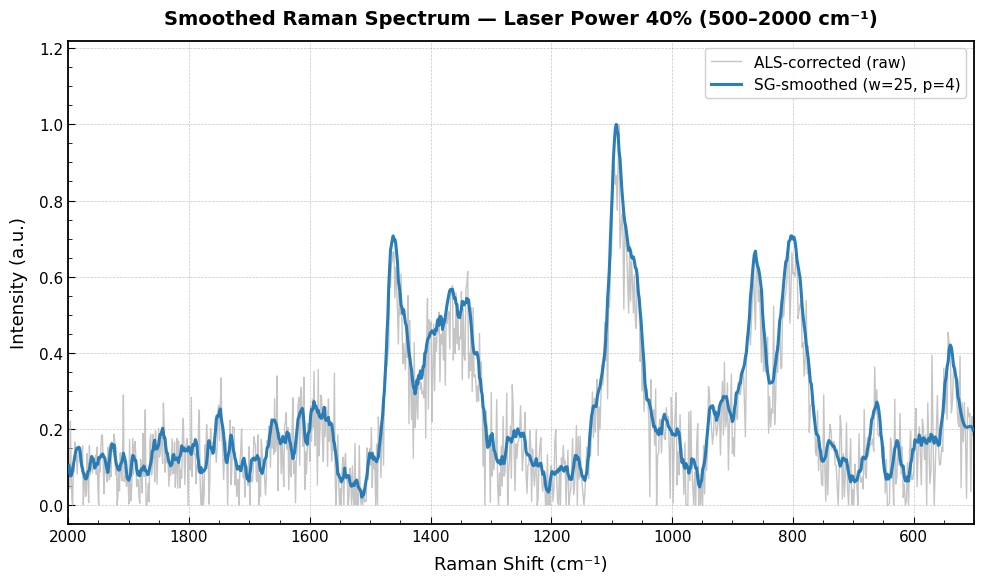

  Saved → raman_smoothed_power_50pct.png  (300 dpi) ✔


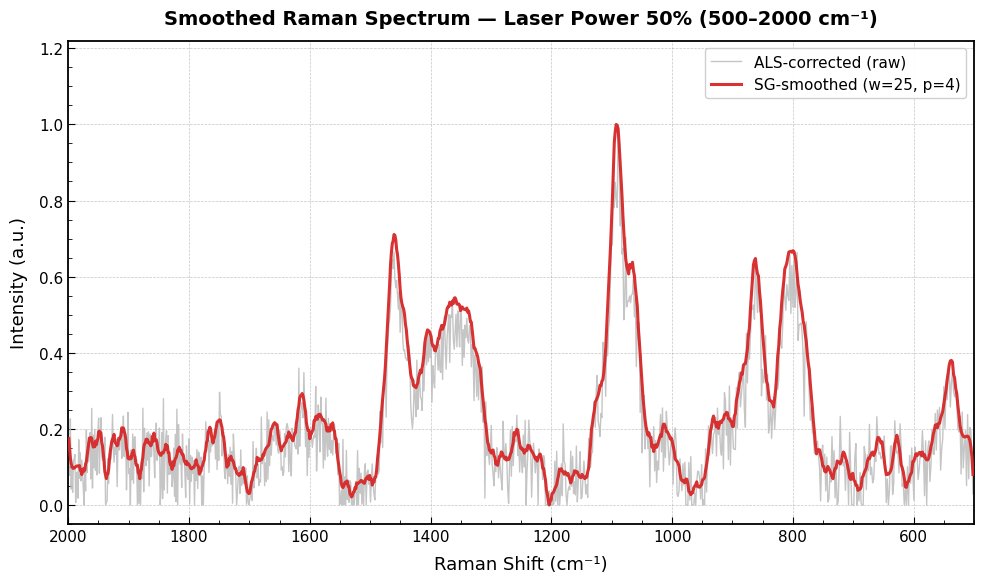

  Saved → raman_smoothed_power_60pct.png  (300 dpi) ✔


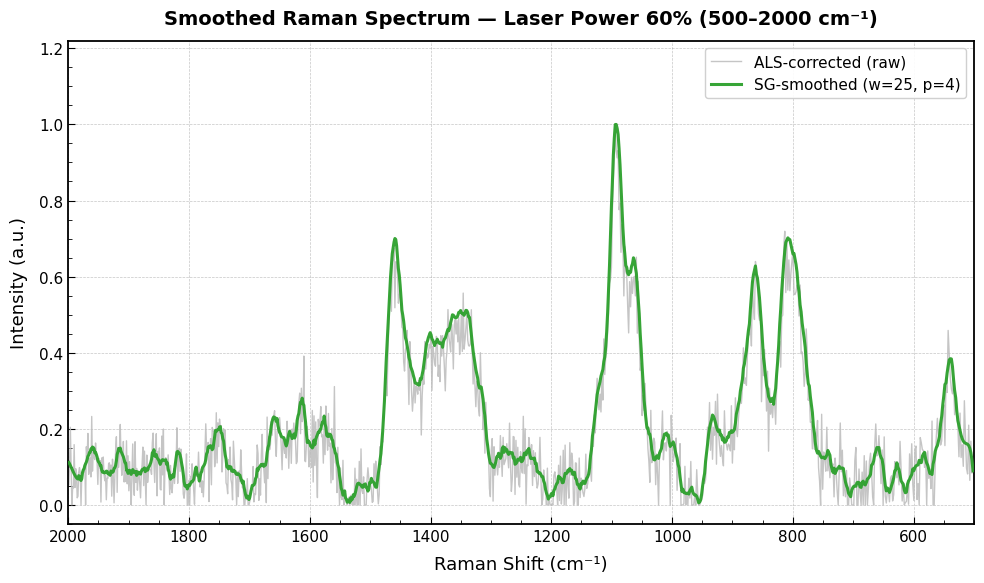

  Saved → raman_smoothed_power_70pct.png  (300 dpi) ✔


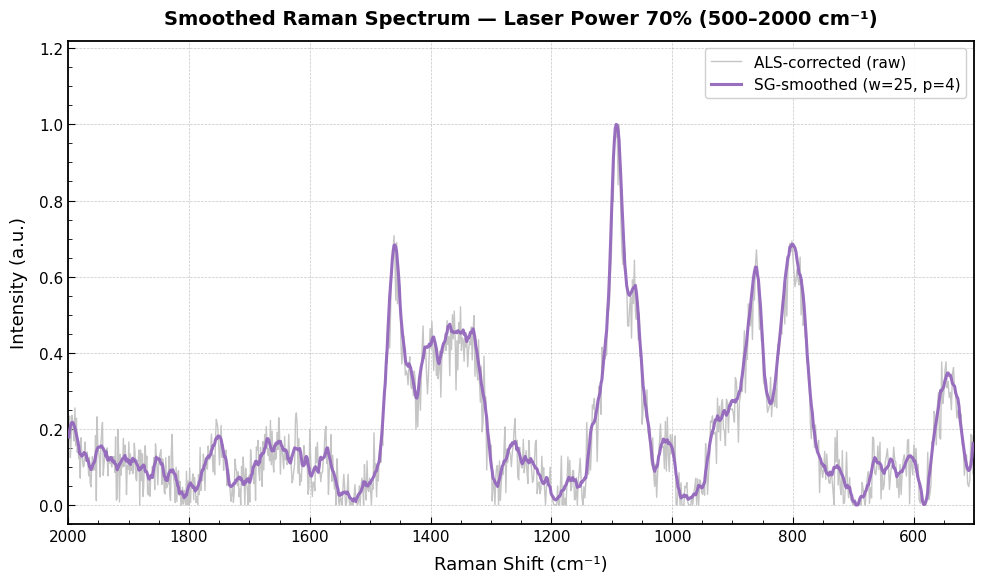


4 smoothed figures saved ✔


In [33]:
saved_smoothed = []

for label, (x_f, y_norm_s) in smoothed_data.items():
    # ── get the unsmoothed normalised trace for overlay ───────────────────────
    y_f_raw  = filtered_data[label][1]
    y_max_r  = y_f_raw.max() if y_f_raw.size > 0 else 1.0
    y_norm_r = y_f_raw / y_max_r if y_max_r > 0 else y_f_raw.copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    # Raw (ALS-corrected, normalised) as thin grey background trace
    ax.plot(x_f, y_norm_r,
            color='#bbbbbb', linewidth=1.0, alpha=0.85,
            label='ALS-corrected (raw)', zorder=2)

    # Smoothed spectrum as bold coloured trace
    ax.plot(x_f, y_norm_s,
            color=COLORS[label], linewidth=2.2,
            label=f'SG-smoothed (w={SG_WINDOW}, p={SG_ORDER})',
            alpha=0.95, zorder=3)

    # Annotation lines
    for shift, lbl in ANNOTATIONS:
        ax.axvline(x=shift, color='#555555', linestyle='--',
                   linewidth=1.1, alpha=0.75, zorder=2)
        ax.text(shift - 8, 1.07, lbl,
                ha='right', va='top', fontsize=8.5,
                color='#444444', linespacing=1.4)

    ax.set_xlim(X_MAX, X_MIN)
    ax.set_ylim(-0.05, 1.22)
    ax.set_xlabel('Raman Shift (cm\u207b\u00b9)', labelpad=8)
    ax.set_ylabel('Intensity (a.u.)',               labelpad=8)
    ax.set_title(
        f'Smoothed Raman Spectrum \u2014 Laser Power {label} '
        f'(500\u20132000 cm\u207b\u00b9)',
        pad=12)

    ax.grid(True, which='major', linestyle='--', linewidth=0.5,
            alpha=0.45, color='grey', zorder=1)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc')

    plt.tight_layout()

    pct = label.replace('%', 'pct')
    out = f'output_images/raman_smoothed_power_{pct}.png'
    fig.savefig(out, dpi=300, bbox_inches='tight', format='png')
    saved_smoothed.append(out)
    print(f'  Saved \u2192 {out}  (300 dpi) \u2714')
    plt.show()

print(f'\n{len(saved_smoothed)} smoothed figures saved \u2714')


## SECTION: Functional Region Annotation (500–2000 cm⁻¹)

Overlay reference-based functional-region bands on the already processed smoothed spectra. These are visual guides only and do not change any earlier plots.

  Saved → raman_functional_regions_power_40pct.png  (300 dpi) ✓


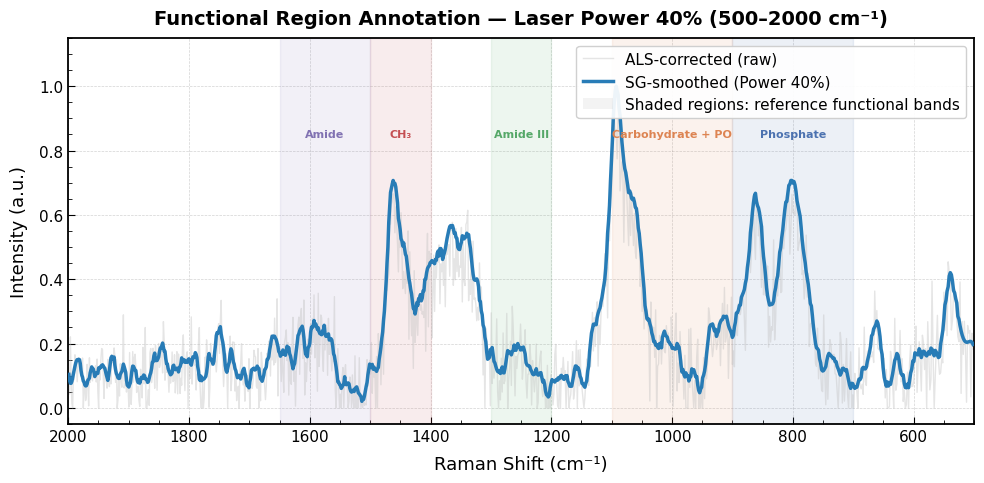

  Saved → raman_functional_regions_power_50pct.png  (300 dpi) ✓


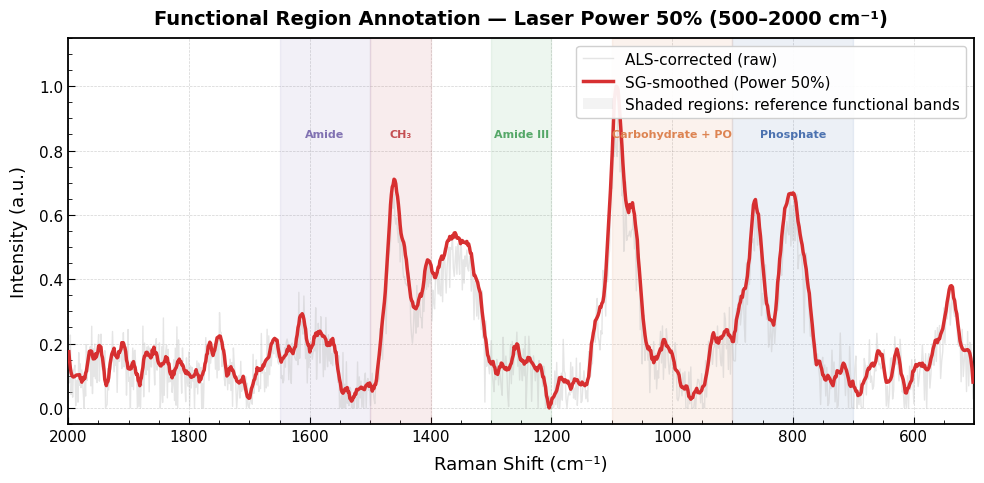

  Saved → raman_functional_regions_power_60pct.png  (300 dpi) ✓


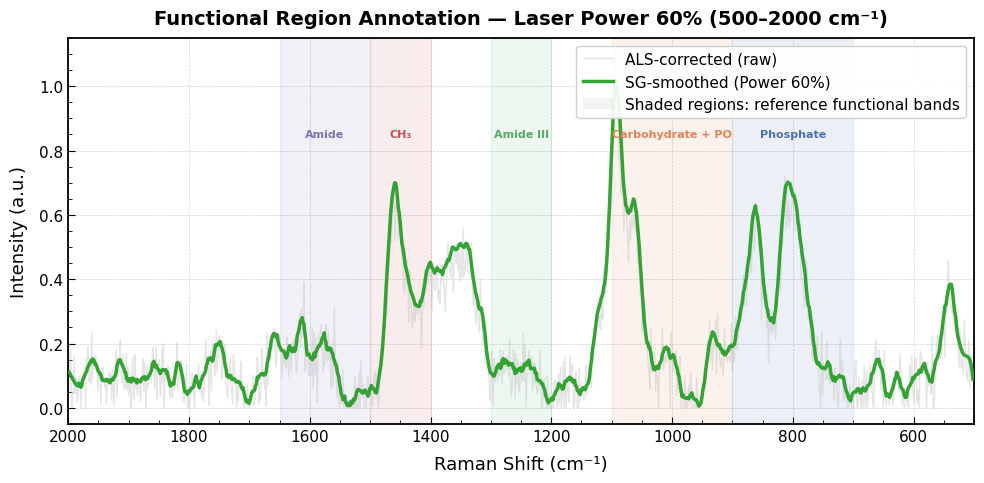

  Saved → raman_functional_regions_power_70pct.png  (300 dpi) ✓


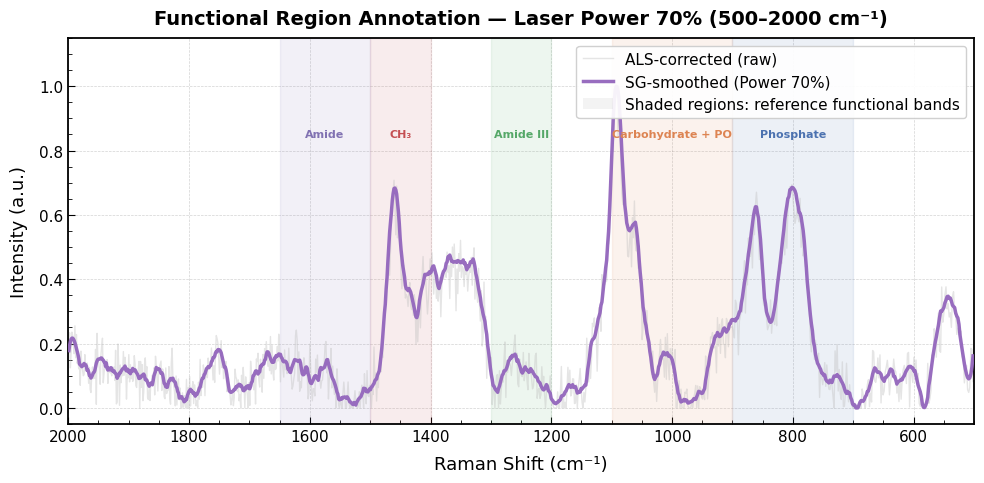

  Saved → raman_functional_regions_combined.png  (300 dpi) ✓


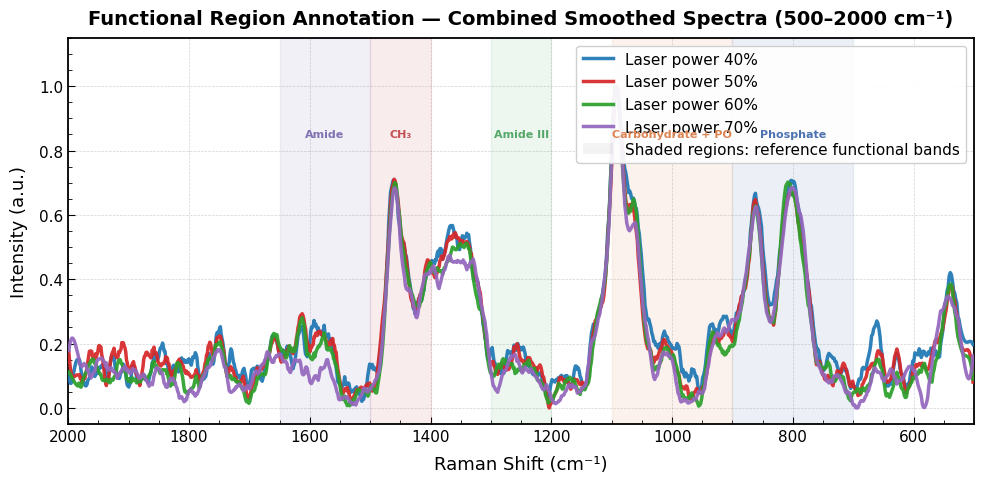


4 functional-region figures saved ✓


In [7]:
from matplotlib.patches import Patch

regions = [
    (700, 900, 'Phosphate', '#4C72B0'),
    (900, 1100, 'Carbohydrate + PO', '#DD8452'),
    (1200, 1300, 'Amide III', '#55A868'),
    (1400, 1500, 'CH₃', '#C44E52'),
    (1500, 1650, 'Amide', '#8172B2'),
]

region_handle = Patch(
    facecolor='#8a8a8a',
    edgecolor='none',
    alpha=0.10,
    label='Shaded regions: reference functional bands',
)


def draw_clean_region_annotations(ax, y_vals):
    y_pos = np.max(y_vals) * 0.85
    for start, end, label, color in regions:
        ax.axvspan(start, end, color=color, alpha=0.10, zorder=1)
        x_center = (start + end) / 2
        ax.text(
            x_center,
            y_pos,
            label,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            color=color,
            zorder=6,
        )


saved_functional_region_files = []
for label, (x_f, y_norm_s) in smoothed_data.items():
    y_f_raw = filtered_data[label][1]
    y_max_r = y_f_raw.max() if y_f_raw.size > 0 else 1.0
    y_norm_r = y_f_raw / y_max_r if y_max_r > 0 else y_f_raw.copy()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        x_f,
        y_norm_r,
        color='#bfbfbf',
        linewidth=1.0,
        alpha=0.4,
        label='ALS-corrected (raw)',
        zorder=2,
    )
    ax.plot(
        x_f,
        y_norm_s,
        color=COLORS[label],
        linewidth=2.5,
        alpha=0.96,
        label=f'SG-smoothed (Power {label})',
        zorder=4,
    )

    draw_clean_region_annotations(ax, y_norm_s)

    ax.set_xlim(X_MAX, X_MIN)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Raman Shift (cm⁻¹)', labelpad=8)
    ax.set_ylabel('Intensity (a.u.)', labelpad=8)
    ax.set_title(
        f'Functional Region Annotation — Laser Power {label} (500–2000 cm⁻¹)',
        pad=10,
    )
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.35, color='grey')
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))

    handles, labels_legend = ax.get_legend_handles_labels()
    handles.append(region_handle)
    labels_legend.append(region_handle.get_label())
    ax.legend(handles, labels_legend, loc='upper right', framealpha=0.92, edgecolor='#cccccc')

    plt.tight_layout()
    out = f'output_images/raman_functional_regions_power_{label.replace("%", "pct")}.png'
    fig.savefig(out, dpi=300, bbox_inches='tight', format='png')
    saved_functional_region_files.append(out)
    print(f'  Saved → {out}  (300 dpi) ✓')
    plt.show()


fig_combined, ax_combined = plt.subplots(figsize=(10, 5))
for label, (x_f, y_norm_s) in smoothed_data.items():
    ax_combined.plot(
        x_f,
        y_norm_s,
        color=COLORS[label],
        linewidth=2.5,
        alpha=0.93,
        label=f'Laser power {label}',
        zorder=4,
    )

reference_x, reference_y = next(iter(smoothed_data.values()))
draw_clean_region_annotations(ax_combined, reference_y)

ax_combined.set_xlim(X_MAX, X_MIN)
ax_combined.set_ylim(-0.05, 1.15)
ax_combined.set_xlabel('Raman Shift (cm⁻¹)', labelpad=8)
ax_combined.set_ylabel('Intensity (a.u.)', labelpad=8)
ax_combined.set_title('Functional Region Annotation — Combined Smoothed Spectra (500–2000 cm⁻¹)', pad=10)
ax_combined.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.35, color='grey')
ax_combined.set_axisbelow(True)
ax_combined.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax_combined.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax_combined.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax_combined.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))

handles, labels_legend = ax_combined.get_legend_handles_labels()
handles.append(region_handle)
labels_legend.append(region_handle.get_label())
ax_combined.legend(handles, labels_legend, loc='upper right', framealpha=0.92, edgecolor='#cccccc')

plt.tight_layout()
combined_out = 'output_images/raman_functional_regions_combined.png'
fig_combined.savefig(combined_out, dpi=300, bbox_inches='tight', format='png')
print(f'  Saved → {combined_out}  (300 dpi) ✓')
plt.show()

print(f'\n{len(saved_functional_region_files)} functional-region figures saved ✓')

## SECTION: Clean Range-Based Functional Region Annotation

Clean shaded-band annotation for region-based comparison with simulation. This section reuses the already processed smoothed spectra and does not alter earlier plots.

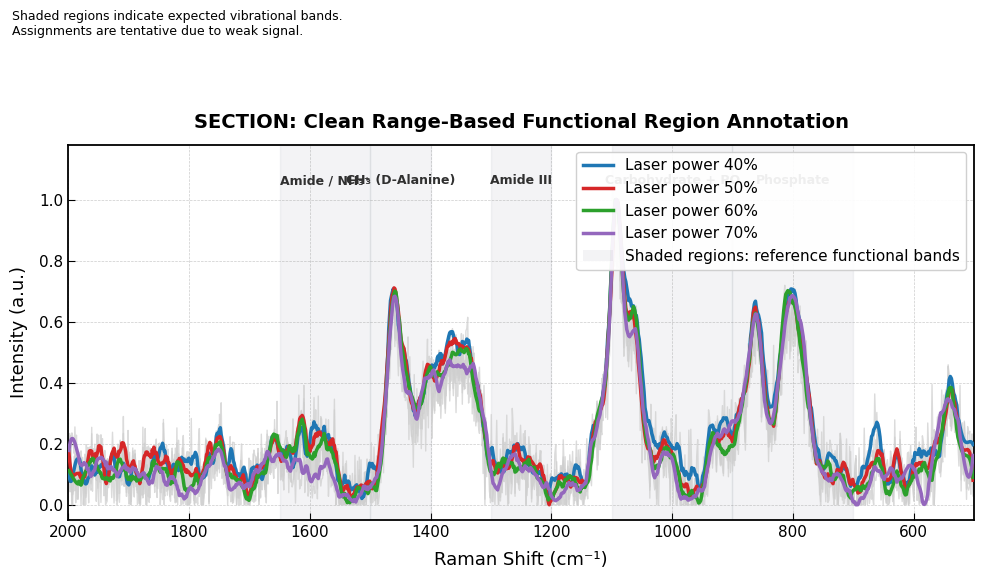

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

regions = [
    (700, 900, 'Phosphate'),
    (900, 1100, 'Carbohydrate + PO'),
    (1200, 1300, 'Amide III'),
    (1400, 1500, 'CH₃ (D-Alanine)'),
    (1500, 1650, 'Amide / NH₃⁺'),
]

if 'smoothed_data' not in globals() or 'filtered_data' not in globals():
    raise RuntimeError('Run the earlier processed-spectra cells first so smoothed_data and filtered_data are available.')

fig, ax = plt.subplots(figsize=(10, 6))

for label, (x_f, y_norm_s) in smoothed_data.items():
    y_f_raw = filtered_data[label][1]
    y_max_r = y_f_raw.max() if y_f_raw.size > 0 else 1.0
    y_norm_r = y_f_raw / y_max_r if y_max_r > 0 else y_f_raw.copy()

    ax.plot(
        x_f,
        y_norm_r,
        color='#cfcfcf',
        linewidth=1.0,
        alpha=0.75,
        zorder=2,
    )
    ax.plot(
        x_f,
        y_norm_s,
        color=COLORS[label],
        linewidth=2.5,
        label=f'Laser power {label}',
        zorder=3,
    )

for start, end, label in regions:
    ax.axvspan(start, end, alpha=0.08, color='#6b7280', zorder=1)

label_y = max(y_vals.max() for _, y_vals in smoothed_data.values()) * 1.05
for start, end, label in regions:
    x_center = (start + end) / 2
    ax.text(
        x_center,
        label_y,
        label,
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#303030',
        zorder=4,
    )

region_proxy = Patch(
    facecolor='#6b7280',
    edgecolor='none',
    alpha=0.08,
    label='Shaded regions: reference functional bands',
)

handles, labels_legend = ax.get_legend_handles_labels()
handles.append(region_proxy)
labels_legend.append(region_proxy.get_label())
ax.legend(handles, labels_legend, loc='upper right', framealpha=0.92, edgecolor='#cccccc')

ax.set_xlim(X_MAX, X_MIN)
ax.set_ylim(-0.05, 1.18)
ax.set_xlabel('Raman Shift (cm⁻¹)', labelpad=8)
ax.set_ylabel('Intensity (a.u.)', labelpad=8)
ax.set_title('SECTION: Clean Range-Based Functional Region Annotation', pad=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4, color='grey')
ax.set_axisbelow(True)
plt.subplots_adjust(top=0.82)
plt.figtext(
    0.02,
    0.92,
    'Shaded regions indicate expected vibrational bands.\nAssignments are tentative due to weak signal.',
    fontsize=9,
)
plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

# SECTION: Functional Region Annotation (500–2000 cm⁻¹)

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Use already processed data: smoothed_data contains (x, y) tuples

# Define spectral regions (ranges, not exact peaks)
regions = [
    (700, 900, "Phosphate (P–O–C stretch)"),
    (900, 1100, "Carbohydrate + Phosphate (C–O–C / PO stretch)"),
    (1200, 1300, "Amide III (C–N / N–H)"),
    (1400, 1500, "CH₃ deformation (D-Alanine)"),
    (1500, 1650, "Amide I / NH₃⁺ / COO⁻ region")
]

# Note text for all plots
note_text = "Note: Regions indicate expected vibrational bands.\nPeak assignments are tentative due to weak signal."

# Combined Plot with Region Annotations
plt.figure(figsize=(12, 7))
for i, (x_f, y_norm_s) in enumerate(smoothed_data):
    try:
        power = files[i].split('_')[1].split('-')[1] + "%"
    except:
        power = files[i]
    plt.plot(x_f, y_norm_s, label=f"Power: {power}", color=COLORS[i], linewidth=1.5)

# Add shading and labels for each region
for start, end, label in regions:
    plt.axvspan(start, end, alpha=0.15, color='gray')
    # Place label at center of region, rotated
    plt.text((start + end) / 2, 1.05, label, rotation=90, 
             fontsize=9, verticalalignment='bottom', horizontalalignment='center')

# Add the specific Note text box
plt.text(1250, 0.5, note_text, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
         fontsize=10, horizontalalignment='center')

plt.xlim(2000, 500)  # Reversed Raman convention
plt.ylim(0, 1.2)     # Normalized intensity scale
plt.xlabel("Raman Shift (cm⁻¹)", fontsize=12)
plt.ylabel("Intensity (a.u.)", fontsize=12)
plt.title("Raman Spectra with Functional Region Annotations", fontsize=14, pad=20)
plt.legend(loc='upper right', frameon=False)
plt.grid(False)
plt.tight_layout()
plt.savefig("output_images/raman_functional_regions_combined.png", dpi=300)
plt.show()

# Individual Plots for each power level
for i, (x_f, y_norm_s) in enumerate(smoothed_data):
    plt.figure(figsize=(10, 5))
    try:
        power = files[i].split('_')[1].split('-')[1] + "%"
    except:
        power = files[i]
    plt.plot(x_f, y_norm_s, color=COLORS[i], linewidth=2)
    
    # Add regions to individual plots
    for start, end, label in regions:
        plt.axvspan(start, end, alpha=0.1, color='gray')
        plt.text((start + end) / 2, 1.05, label, rotation=90, 
                 fontsize=8, verticalalignment='bottom', horizontalalignment='center')
    
    plt.text(1250, 0.5, note_text, bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'),
             fontsize=9, horizontalalignment='center')
             
    plt.xlim(2000, 500)
    plt.ylim(0, 1.2)
    plt.xlabel("Raman Shift (cm⁻¹)")
    plt.ylabel("Intensity (a.u.)")
    plt.title(f"Functional Regions - Laser Power {power}")
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"output_images/raman_functional_regions_power_{power.replace('%', 'pct')}.png", dpi=300)
    plt.show()

ValueError: too many values to unpack (expected 2)

<Figure size 1200x700 with 0 Axes>